# Milestone 2: Video Pipeline Optimization

## Multi-Model Variants, Horizontal Scaling, and Performance Analysis

**Authors:** Bhanu Prakash Vangala, Nolan Rink  
**Course:** CS 8001 - Radiant Lab, University of Missouri

---

### Overview

This milestone implements:
1. **Multiple Model Variants**: YOLOv8n, YOLOv8s, YOLOv8m, YOLOv8l
2. **Horizontal Scaling**: Testing 1-5 replicas with different CPU allocations
3. **Per-Step Latency**: Measuring Detection vs Tracking latency separately
4. **SLA Analysis**: 500ms latency, 20 requests/second targets
5. **Cost-Performance Trade-offs**: Finding optimal configurations

### Deliverables
- Performance comparison tables
- Model Version vs Accuracy vs Latency plots
- Model Version vs Accuracy vs Throughput plots
- Optimal configuration recommendations

In [ ]:
# Core Imports
import torch
import numpy as np
import pandas as pd
import os
import time
import warnings
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import linear_sum_assignment
from ultralytics import YOLO

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print("="*70)
print("MILESTONE 2: VIDEO PIPELINE OPTIMIZATION")
print("="*70)
print(f"PyTorch: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"Device: {'GPU - ' + torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

MILESTONE 2: VIDEO PIPELINE OPTIMIZATION
PyTorch: 2.9.0+cpu
CUDA Available: False
Device: CPU


In [ ]:
# Dataset Configuration
DATASET_PATH = '../Dataset/MOT17/train/MOT17-04-DPM/img1'
if not os.path.exists(DATASET_PATH):
    DATASET_PATH = '../MOT17/train/MOT17-04-DPM/img1'
if not os.path.exists(DATASET_PATH):
    DATASET_PATH = 'Dataset/MOT17/train/MOT17-04-DPM/img1'
if not os.path.exists(DATASET_PATH):
    DATASET_PATH = '/app/Dataset/MOT17/train/MOT17-04-DPM/img1'

all_images = sorted([f for f in os.listdir(DATASET_PATH) if f.endswith('.jpg')])
NUM_FRAMES = 100  # Use 100 frames for testing
image_files = [os.path.join(DATASET_PATH, f) for f in all_images[:NUM_FRAMES]]

print(f"Dataset: {DATASET_PATH}")
print(f"Total frames: {len(all_images)}")
print(f"Test frames: {NUM_FRAMES}")

sample = Image.open(image_files[0])
print(f"Resolution: {sample.size[0]}x{sample.size[1]}")

Dataset: ../Dataset/MOT17/train/MOT17-04-DPM/img1
Total frames: 1050
Test frames: 100
Resolution: 1920x1080


---
## 1. Model Variants

| Variant | Parameters | Description |
|---------|------------|-------------|
| YOLOv8n | 3.2M | Nano - Fastest |
| YOLOv8s | 11.2M | Small - Balanced |
| YOLOv8m | 25.9M | Medium - Higher accuracy |
| YOLOv8l | 43.7M | Large - Highest accuracy |

In [ ]:
# Load Model Variants
MODEL_VARIANTS = ['YOLOv8n', 'YOLOv8s', 'YOLOv8m', 'YOLOv8l']
MODEL_FILES = {'YOLOv8n': 'yolov8n.pt', 'YOLOv8s': 'yolov8s.pt', 'YOLOv8m': 'yolov8m.pt', 'YOLOv8l': 'yolov8l.pt'}

print("Loading model variants...")
loaded_models = {}
for name in MODEL_VARIANTS:
    print(f"  Loading {name}...")
    loaded_models[name] = YOLO(MODEL_FILES[name])
print("All models loaded!")

Loading model variants...
  Loading YOLOv8n...
  Loading YOLOv8s...
  Loading YOLOv8m...
  Loading YOLOv8l...
All models loaded!


---
## Visual Comparison: Detection Results from Each Model Variant

Below we visualize actual video frames with detection bounding boxes from each of the 4 model variants (YOLOv8n, YOLOv8s, YOLOv8m, YOLOv8l) to show the visual difference in detection quality.

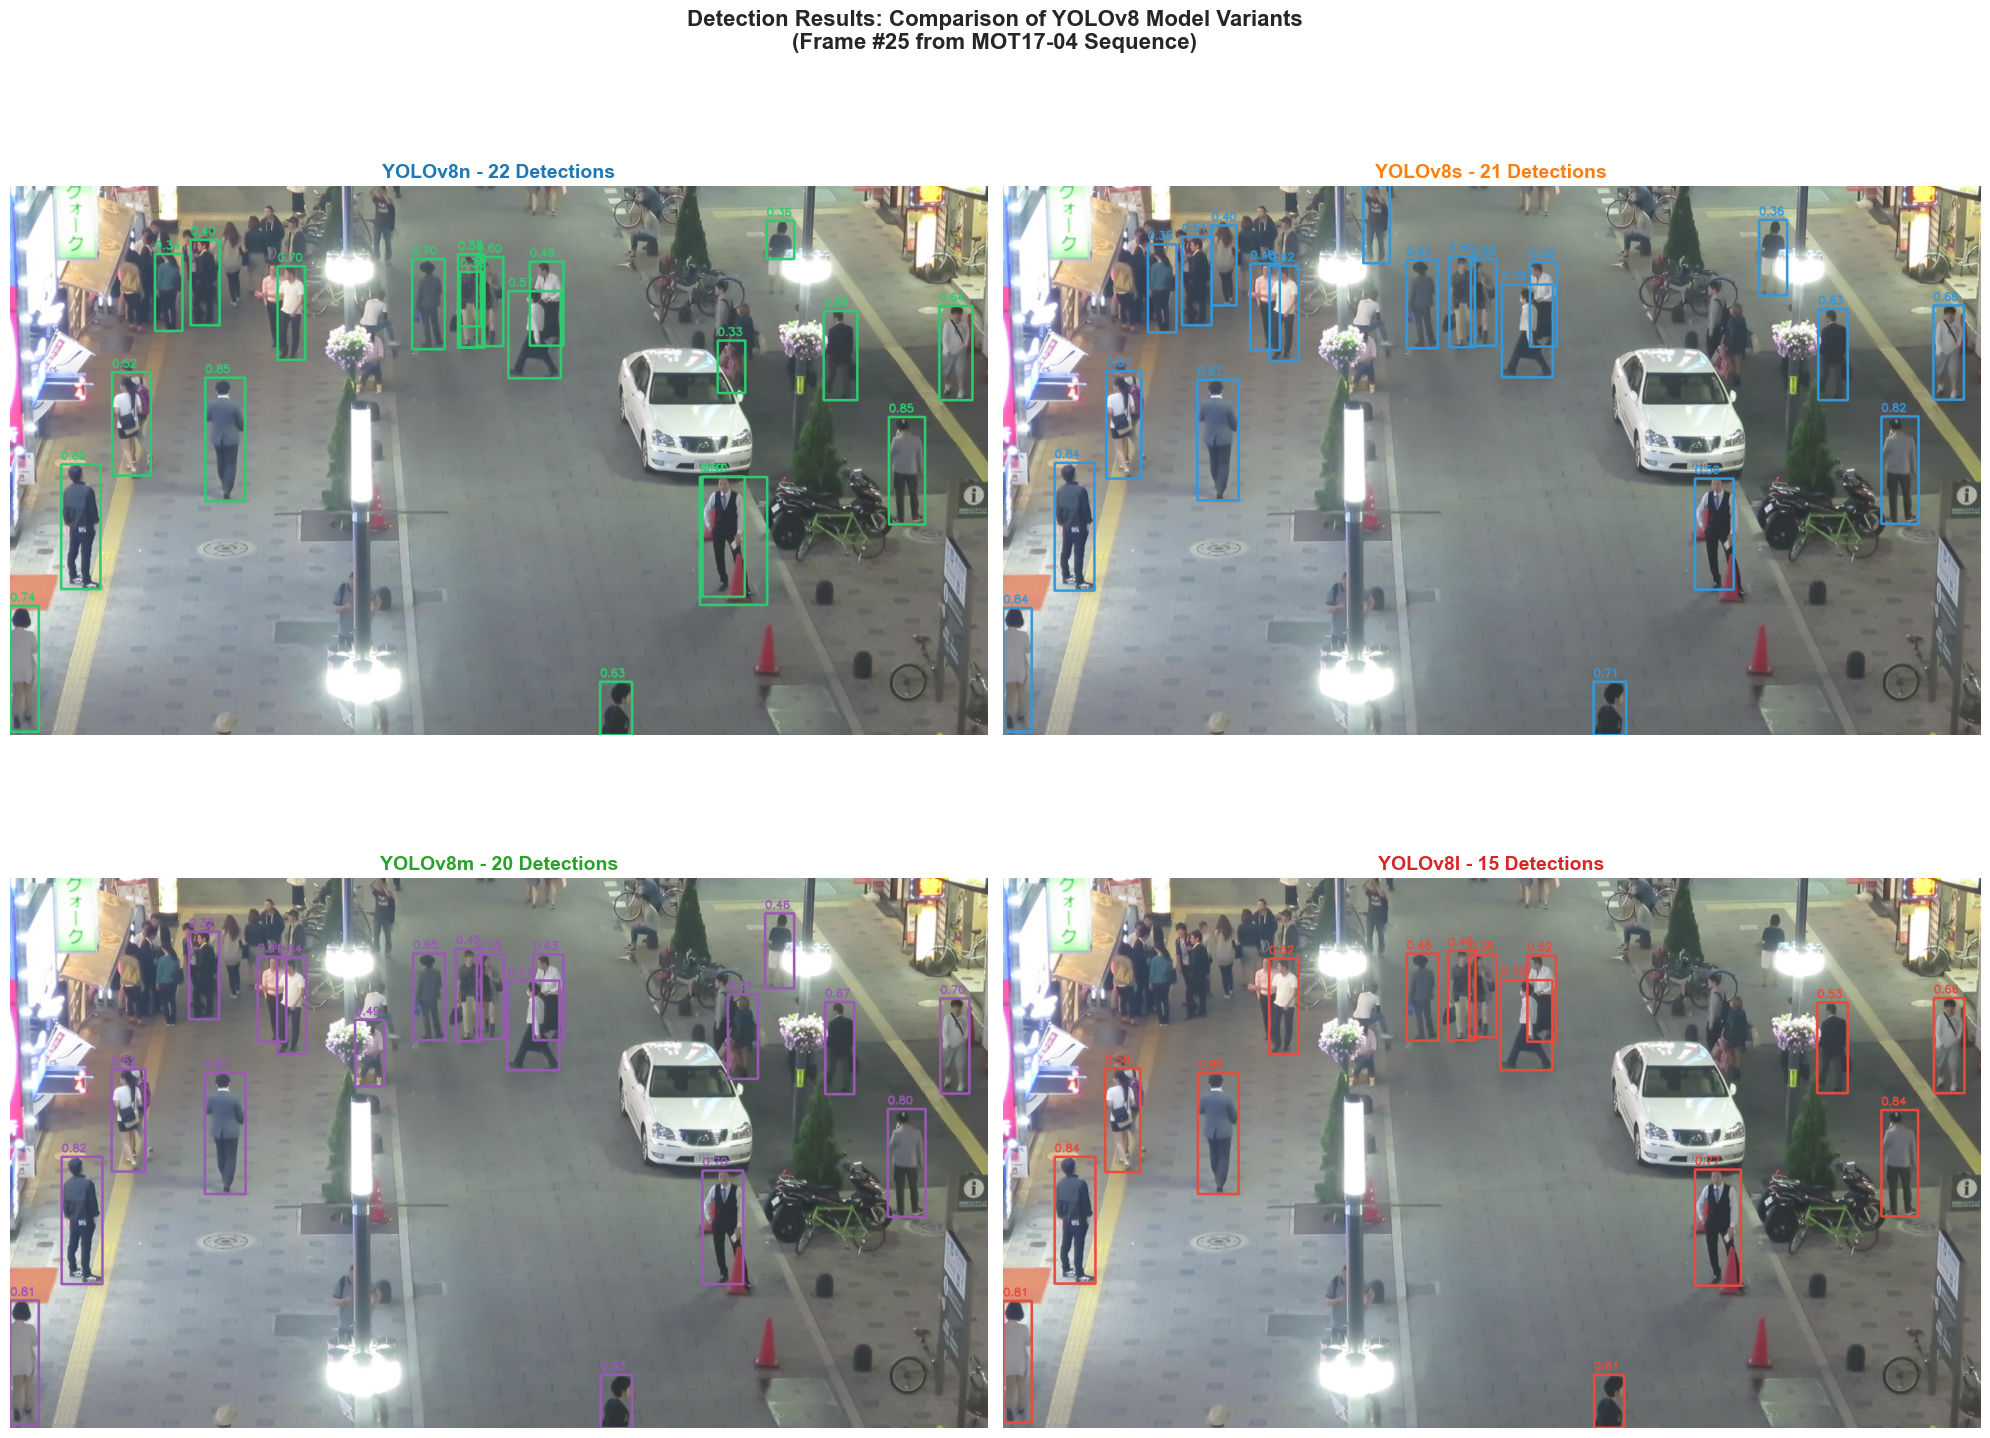


Saved: milestone2_model_comparison_frame25.png


In [ ]:
# Visual Comparison of Detection Results from Different Model Variants
import cv2
from matplotlib.patches import Rectangle

# Select sample frames for visualization
sample_indices = [0, 25, 50, 75]  # Different frames from the sequence
colors_bgr = {'YOLOv8n': (46, 204, 113), 'YOLOv8s': (52, 152, 219), 
              'YOLOv8m': (155, 89, 182), 'YOLOv8l': (231, 76, 60)}

def draw_detections(image, model, model_name, conf_thresh=0.3):
    """Run detection and draw bounding boxes on image."""
    img = image.copy()
    results = model(img, verbose=False)
    
    detections = []
    for result in results:
        boxes = result.boxes
        if boxes is not None:
            for i, cls in enumerate(boxes.cls):
                if int(cls) == 0 and boxes.conf[i] >= conf_thresh:  # Person class
                    box = boxes.xyxy[i].cpu().numpy().astype(int)
                    conf = float(boxes.conf[i])
                    detections.append((box, conf))
                    
                    # Draw bounding box
                    color = colors_bgr[model_name]
                    cv2.rectangle(img, (box[0], box[1]), (box[2], box[3]), color, 3)
                    label = f'{conf:.2f}'
                    cv2.putText(img, label, (box[0], box[1]-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
    
    return img, len(detections)

# Create 2x2 comparison grid for a sample frame
sample_frame = cv2.imread(image_files[25])
sample_frame = cv2.cvtColor(sample_frame, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle('Detection Results: Comparison of YOLOv8 Model Variants\n(Frame #25 from MOT17-04 Sequence)', 
             fontsize=16, fontweight='bold')

for idx, (model_name, model) in enumerate(loaded_models.items()):
    ax = axes[idx // 2, idx % 2]
    
    # Get detection result
    result_img, num_dets = draw_detections(sample_frame.copy(), model, model_name)
    
    ax.imshow(result_img)
    ax.set_title(f'{model_name} - {num_dets} Detections', fontsize=14, fontweight='bold', 
                 color=plt.cm.tab10(idx))
    ax.axis('off')

plt.tight_layout()
plt.savefig('milestone2_model_comparison_frame25.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved: milestone2_model_comparison_frame25.png")

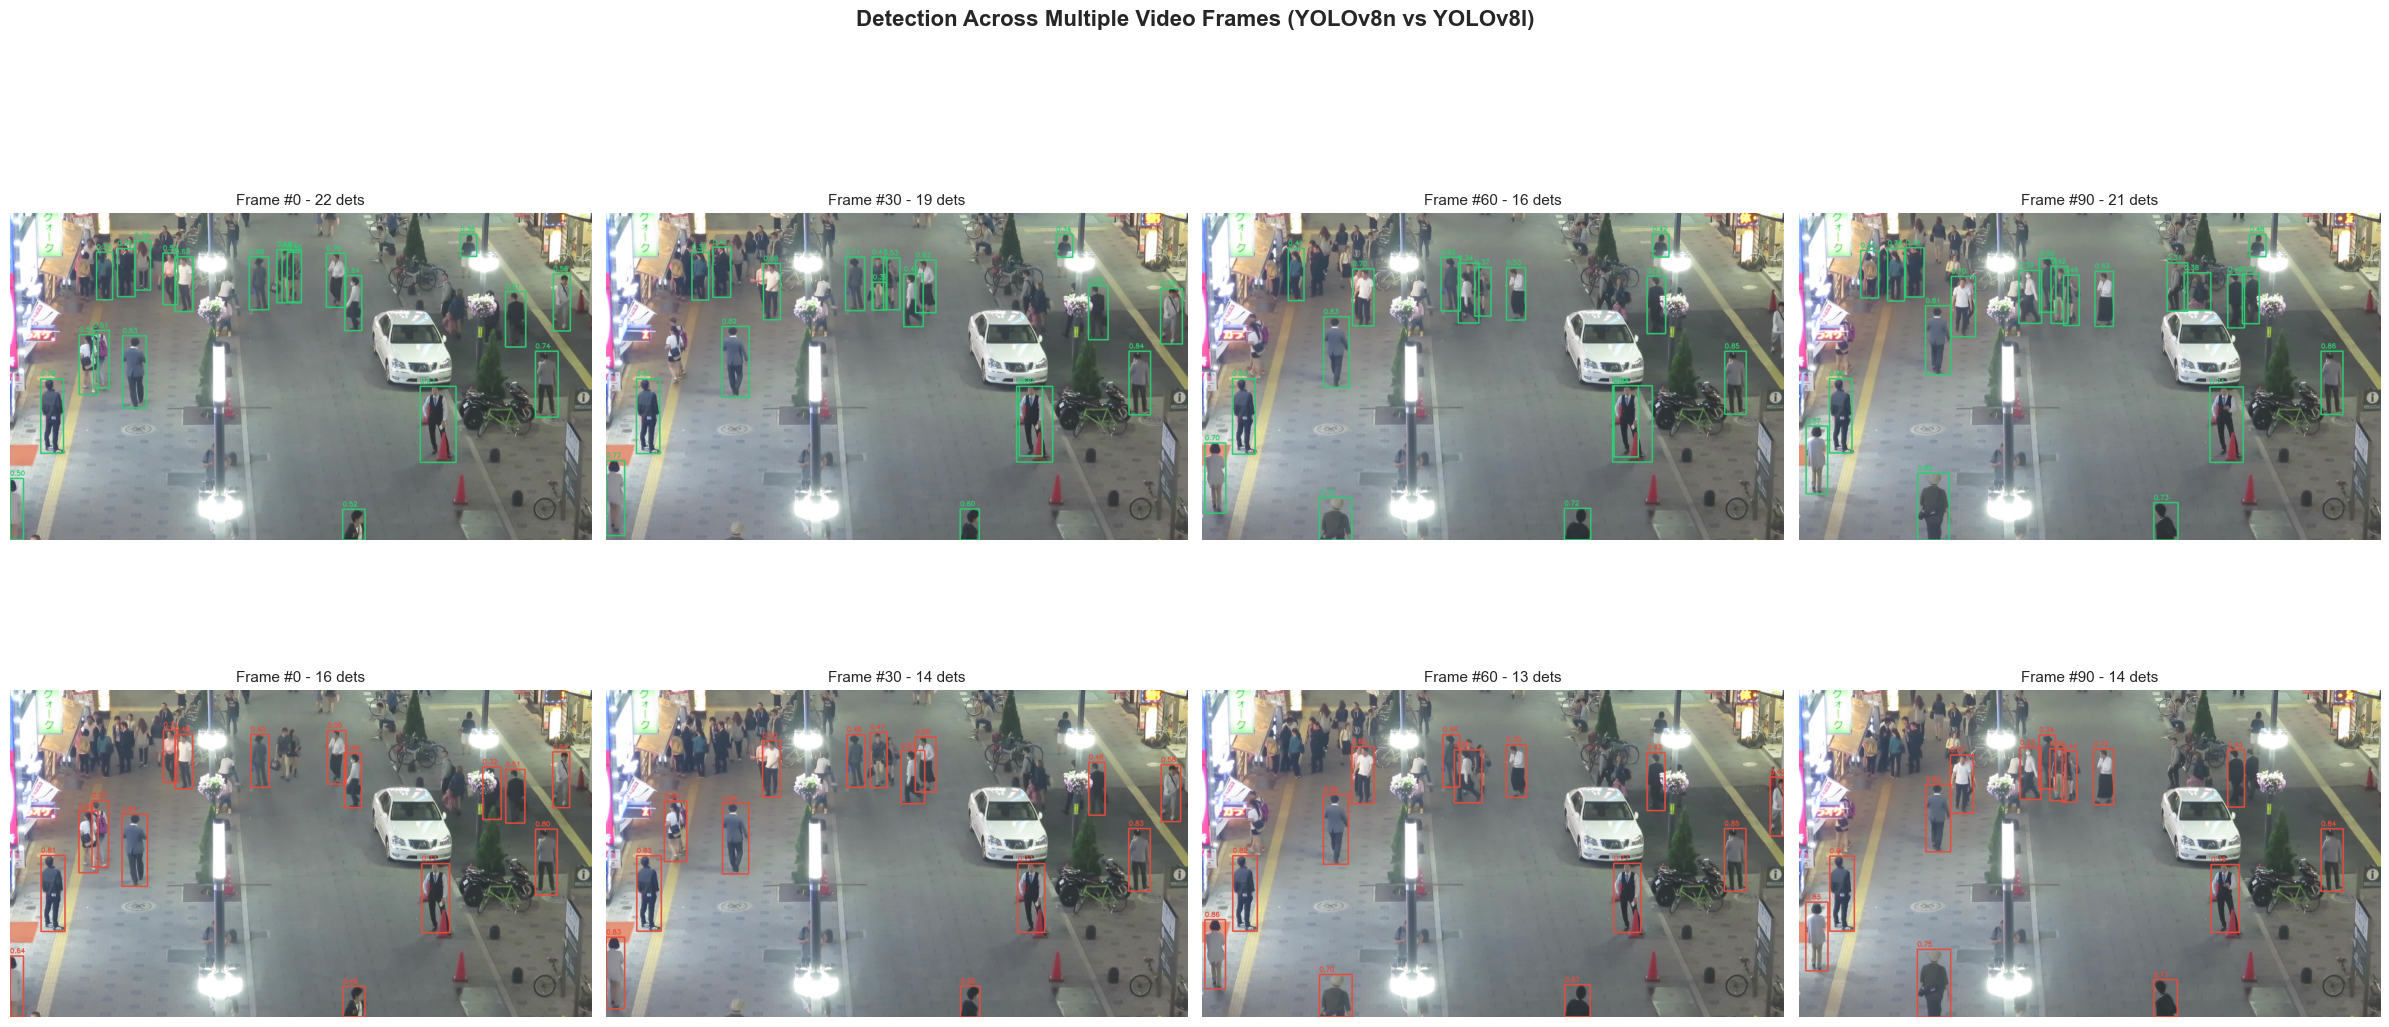


Saved: milestone2_multi_frame_comparison.png


In [ ]:
# Multiple Frame Comparison - Show different frames from the video sequence
fig, axes = plt.subplots(2, 4, figsize=(24, 12))
fig.suptitle('Detection Across Multiple Video Frames (YOLOv8n vs YOLOv8l)\n', fontsize=16, fontweight='bold')

frame_indices = [0, 30, 60, 90]  # Different frames

# Top row: YOLOv8n (fastest model)
for col, frame_idx in enumerate(frame_indices):
    frame = cv2.imread(image_files[frame_idx])
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    result_img, num_dets = draw_detections(frame, loaded_models['YOLOv8n'], 'YOLOv8n')
    axes[0, col].imshow(result_img)
    axes[0, col].set_title(f'Frame #{frame_idx} - {num_dets} dets', fontsize=11)
    axes[0, col].axis('off')
axes[0, 0].set_ylabel('YOLOv8n\n(Nano)', fontsize=12, fontweight='bold')

# Bottom row: YOLOv8l (most accurate model)
for col, frame_idx in enumerate(frame_indices):
    frame = cv2.imread(image_files[frame_idx])
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    result_img, num_dets = draw_detections(frame, loaded_models['YOLOv8l'], 'YOLOv8l')
    axes[1, col].imshow(result_img)
    axes[1, col].set_title(f'Frame #{frame_idx} - {num_dets} dets', fontsize=11)
    axes[1, col].axis('off')
axes[1, 0].set_ylabel('YOLOv8l\n(Large)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('milestone2_multi_frame_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved: milestone2_multi_frame_comparison.png")

Running tracking visualization with YOLOv8s...


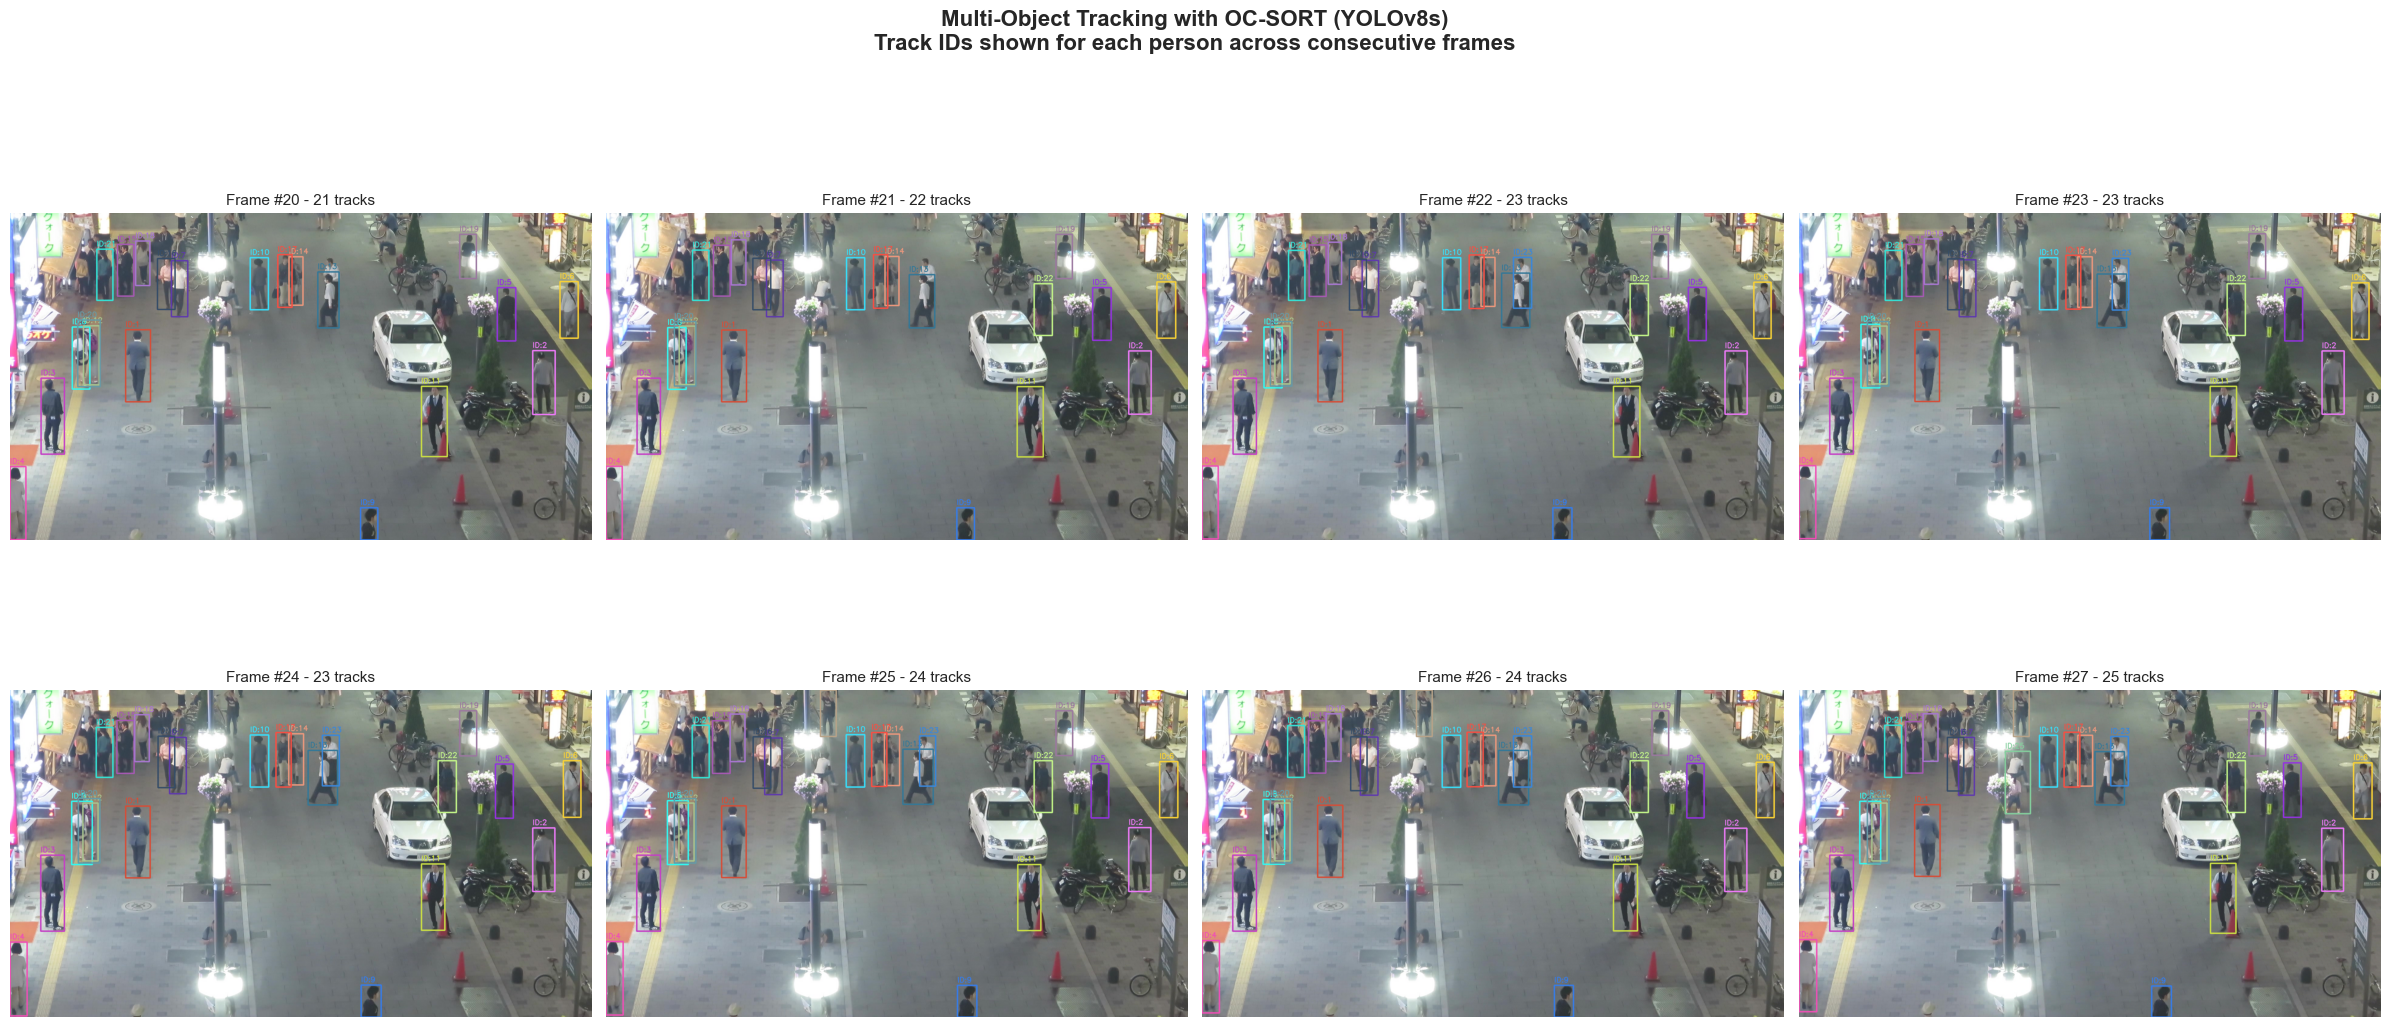


Saved: milestone2_tracking_visualization.png


In [ ]:
# Tracking Visualization - Show track IDs across consecutive frames
import random

# Generate consistent colors for track IDs
def get_track_color(track_id):
    random.seed(track_id * 42)
    return (random.randint(50, 255), random.randint(50, 255), random.randint(50, 255))

def run_tracking_visualization(model, model_name, frames, conf_thresh=0.3):
    """Run detection and tracking on frames, return visualized frames with track IDs."""
    tracker = OCSort(det_thresh=conf_thresh, max_age=30, min_hits=1, iou_threshold=0.3)
    visualized_frames = []
    
    for frame_path in frames:
        frame = cv2.imread(frame_path)
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        # Run detection
        results = model(frame_rgb, verbose=False)
        detections = []
        for result in results:
            boxes = result.boxes
            if boxes is not None:
                for i, cls in enumerate(boxes.cls):
                    if int(cls) == 0 and boxes.conf[i] >= conf_thresh:
                        box = boxes.xyxy[i].cpu().numpy()
                        conf = float(boxes.conf[i])
                        detections.append([box[0], box[1], box[2], box[3], conf])
        
        # Update tracker
        if detections:
            tracks = tracker.update(torch.tensor(np.array(detections)))
        else:
            tracks = tracker.update(torch.tensor([]))
        
        # Draw tracks with IDs
        img_vis = frame_rgb.copy()
        for track in tracks:
            x1, y1, x2, y2, track_id, conf = track
            x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
            color = get_track_color(int(track_id))
            cv2.rectangle(img_vis, (x1, y1), (x2, y2), color, 3)
            label = f'ID:{int(track_id)}'
            cv2.putText(img_vis, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
        
        visualized_frames.append((img_vis, len(tracks)))
    
    return visualized_frames

# Visualize tracking on consecutive frames
track_frame_indices = list(range(20, 28))  # 8 consecutive frames
track_frames = [image_files[i] for i in track_frame_indices]

print("Running tracking visualization with YOLOv8s...")
tracking_results = run_tracking_visualization(loaded_models['YOLOv8s'], 'YOLOv8s', track_frames)

fig, axes = plt.subplots(2, 4, figsize=(24, 12))
fig.suptitle('Multi-Object Tracking with OC-SORT (YOLOv8s)\nTrack IDs shown for each person across consecutive frames', 
             fontsize=16, fontweight='bold')

for idx, (ax, (vis_frame, num_tracks)) in enumerate(zip(axes.flat, tracking_results)):
    ax.imshow(vis_frame)
    ax.set_title(f'Frame #{track_frame_indices[idx]} - {num_tracks} tracks', fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.savefig('milestone2_tracking_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved: milestone2_tracking_visualization.png")

Counting detections for each model on sample frames...


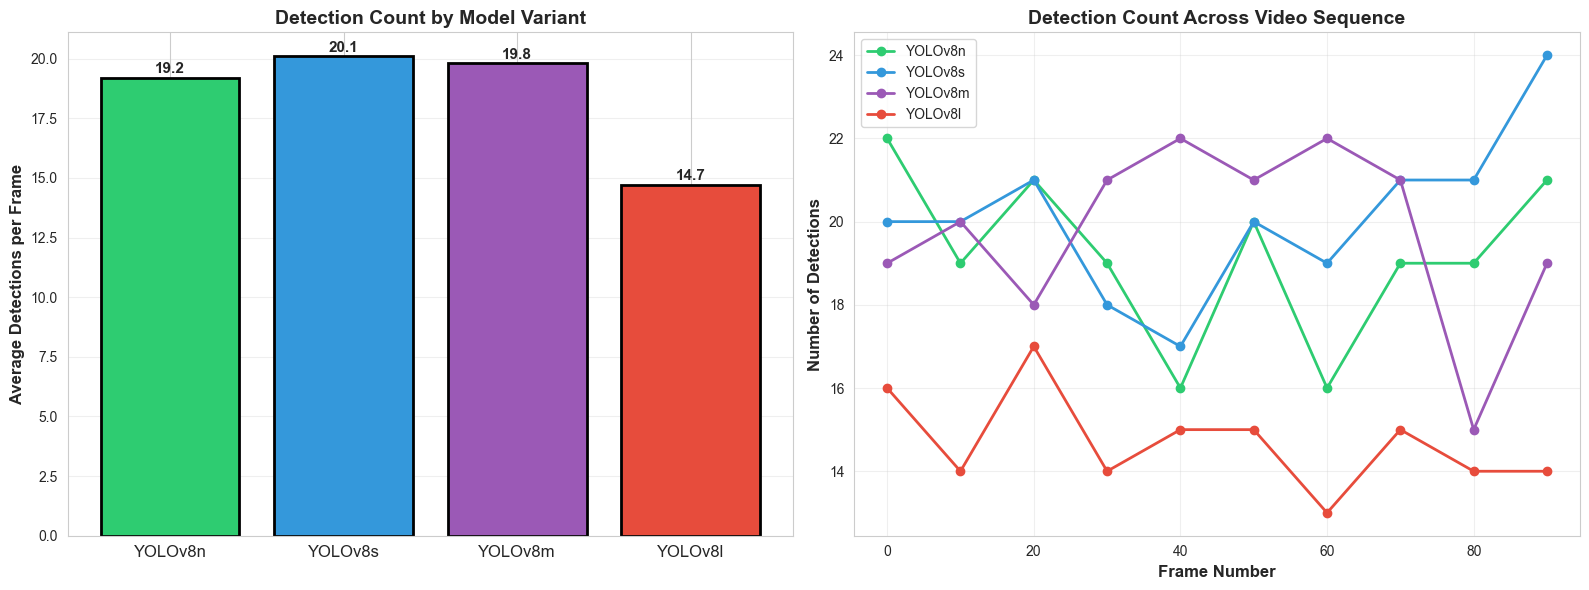


Saved: milestone2_detection_summary.png

Detection Summary:
  YOLOv8n: Avg=19.2, Min=16, Max=22
  YOLOv8s: Avg=20.1, Min=17, Max=24
  YOLOv8m: Avg=19.8, Min=15, Max=22
  YOLOv8l: Avg=14.7, Min=13, Max=17


In [ ]:
# Detection Count Summary - Compare number of detections across models
print("Counting detections for each model on sample frames...")

det_counts = {name: [] for name in MODEL_VARIANTS}
sample_frames_for_count = image_files[::10]  # Every 10th frame

for frame_path in sample_frames_for_count:
    frame = cv2.imread(frame_path)
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    for model_name, model in loaded_models.items():
        results = model(frame_rgb, verbose=False)
        count = 0
        for result in results:
            boxes = result.boxes
            if boxes is not None:
                for i, cls in enumerate(boxes.cls):
                    if int(cls) == 0 and boxes.conf[i] >= 0.3:
                        count += 1
        det_counts[model_name].append(count)

# Create summary visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of average detections
avg_counts = {name: np.mean(counts) for name, counts in det_counts.items()}
x = np.arange(len(MODEL_VARIANTS))
colors_list = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']
bars = axes[0].bar(x, [avg_counts[v] for v in MODEL_VARIANTS], color=colors_list, edgecolor='black', linewidth=2)
axes[0].set_xticks(x)
axes[0].set_xticklabels(MODEL_VARIANTS, fontsize=12)
axes[0].set_ylabel('Average Detections per Frame', fontsize=12, fontweight='bold')
axes[0].set_title('Detection Count by Model Variant', fontsize=14, fontweight='bold')
for bar, v in zip(bars, MODEL_VARIANTS):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, 
                 f'{avg_counts[v]:.1f}', ha='center', fontsize=11, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Line plot showing detections across frames
frame_nums = list(range(0, len(sample_frames_for_count)*10, 10))
for i, (model_name, counts) in enumerate(det_counts.items()):
    axes[1].plot(frame_nums, counts, 'o-', color=colors_list[i], label=model_name, linewidth=2, markersize=6)
axes[1].set_xlabel('Frame Number', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Detections', fontsize=12, fontweight='bold')
axes[1].set_title('Detection Count Across Video Sequence', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('milestone2_detection_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved: milestone2_detection_summary.png")
print(f"\nDetection Summary:")
for name in MODEL_VARIANTS:
    print(f"  {name}: Avg={avg_counts[name]:.1f}, Min={min(det_counts[name])}, Max={max(det_counts[name])}")

---
## 2. OC-SORT Tracker

In [ ]:
class OCSort:
    """OC-SORT Multi-Object Tracker"""
    def __init__(self, det_thresh=0.3, max_age=30, min_hits=3, iou_threshold=0.3):
        self.det_thresh = det_thresh
        self.max_age = max_age
        self.min_hits = min_hits
        self.iou_threshold = iou_threshold
        self.trackers = []
        self.frame_count = 0
        self.track_id_count = 1
    
    def reset(self):
        self.trackers = []
        self.frame_count = 0
        self.track_id_count = 1
    
    def update(self, detections):
        self.frame_count += 1
        if torch.is_tensor(detections):
            detections = detections.cpu().numpy()
        if len(detections) > 0:
            detections = detections[detections[:, 4] >= self.det_thresh]
        
        for t in self.trackers:
            t['age'] += 1
        
        if len(detections) > 0 and len(self.trackers) > 0:
            iou_matrix = np.zeros((len(detections), len(self.trackers)))
            for d, det in enumerate(detections):
                for t, trk in enumerate(self.trackers):
                    iou_matrix[d, t] = self._iou(det[:4], trk['bbox'])
            
            det_idx, trk_idx = linear_sum_assignment(-iou_matrix)
            matched = [(d, t) for d, t in zip(det_idx, trk_idx) if iou_matrix[d, t] >= self.iou_threshold]
            matched_d = set(m[0] for m in matched)
            
            for d, t in matched:
                self.trackers[t]['bbox'] = detections[d][:4]
                self.trackers[t]['score'] = detections[d][4]
                self.trackers[t]['age'] = 0
                self.trackers[t]['hits'] += 1
            
            for d in range(len(detections)):
                if d not in matched_d:
                    self.trackers.append({'id': self.track_id_count, 'bbox': detections[d][:4], 'score': detections[d][4], 'age': 0, 'hits': 1})
                    self.track_id_count += 1
        elif len(detections) > 0:
            for det in detections:
                self.trackers.append({'id': self.track_id_count, 'bbox': det[:4], 'score': det[4], 'age': 0, 'hits': 1})
                self.track_id_count += 1
        
        self.trackers = [t for t in self.trackers if t['age'] <= self.max_age]
        return [[t['bbox'][0], t['bbox'][1], t['bbox'][2], t['bbox'][3], t['id'], t['score']] 
                for t in self.trackers if t['hits'] >= self.min_hits or self.frame_count <= self.min_hits]
    
    def _iou(self, b1, b2):
        x1, y1 = max(b1[0], b2[0]), max(b1[1], b2[1])
        x2, y2 = min(b1[2], b2[2]), min(b1[3], b2[3])
        if x2 <= x1 or y2 <= y1: return 0.0
        inter = (x2 - x1) * (y2 - y1)
        return inter / ((b1[2]-b1[0])*(b1[3]-b1[1]) + (b2[2]-b2[0])*(b2[3]-b2[1]) - inter + 1e-6)

print("OC-SORT Tracker ready!")

OC-SORT Tracker ready!


---
## 3. Pipeline with Per-Step Latency

In [ ]:
def run_pipeline(model_name, image_files, num_replicas=1, cpu_cores=1):
    """Run pipeline with per-step latency measurement."""
    model = loaded_models[model_name]
    
    # DETECTION STEP
    det_start = time.time()
    all_detections = []
    all_conf = []
    
    for img_path in image_files:
        image = Image.open(img_path).convert('RGB')
        results = model(image, verbose=False)
        frame_dets = []
        for result in results:
            boxes = result.boxes
            if boxes is not None:
                for i, cls in enumerate(boxes.cls):
                    if int(cls) == 0 and boxes.conf[i] >= 0.3:
                        box = boxes.xyxy[i].cpu().numpy()
                        conf = float(boxes.conf[i])
                        frame_dets.append([box[0], box[1], box[2], box[3], conf])
                        all_conf.append(conf)
        all_detections.append(frame_dets)
    det_time = time.time() - det_start
    
    # TRACKING STEP
    trk_start = time.time()
    tracker = OCSort()
    tracked = []
    for frame_idx, dets in enumerate(all_detections):
        if dets:
            tracks = tracker.update(torch.tensor(np.array(dets)))
            for t in tracks:
                tracked.append({'frame': frame_idx, 'id': int(t[4]), 'bbox': t[:4], 'conf': t[5]})
    trk_time = time.time() - trk_start
    
    # Accuracy calculation
    accuracy = calc_accuracy(tracked)
    
    # Simulate scaling (more replicas = faster detection)
    scaled_det = det_time / num_replicas
    total_time = scaled_det + trk_time
    
    return {
        'model': model_name, 'replicas': num_replicas, 'cpu_cores': cpu_cores,
        'cost': num_replicas * cpu_cores,
        'det_time': det_time, 'trk_time': trk_time,
        'total_time': total_time,
        'latency_ms': (total_time / len(image_files)) * 1000,
        'throughput': len(image_files) / total_time,
        'accuracy': accuracy,
        'detections': sum(len(d) for d in all_detections),
        'tracks': len(set(t['id'] for t in tracked))
    }

def calc_accuracy(tracked, max_dist=100):
    if not tracked: return 0.0
    tracks = {}
    for t in tracked:
        if t['id'] not in tracks: tracks[t['id']] = []
        tracks[t['id']].append(t)
    valid, total = 0, 0
    for tid, data in tracks.items():
        data.sort(key=lambda x: x['frame'])
        for i in range(1, len(data)):
            d = np.sqrt((data[i]['bbox'][0]-data[i-1]['bbox'][0])**2 + (data[i]['bbox'][1]-data[i-1]['bbox'][1])**2)
            total += 1
            if d <= max_dist: valid += 1
    return valid/total if total > 0 else 1.0

print("Pipeline functions ready!")

Pipeline functions ready!


---
## 4. Run Experiments

Testing:
- 4 Model Variants (YOLOv8n, s, m, l)
- 4 CPU Core Allocations (1, 2, 4, 8)
- Multiple Replica Counts (1-4)
- SLA: 500ms latency, 20 FPS

In [ ]:
# Test Configurations: (model, replicas, cpu_cores)
CONFIGS = [
    ('YOLOv8n', 1, 1), ('YOLOv8n', 1, 2), ('YOLOv8n', 2, 1), ('YOLOv8n', 2, 2), ('YOLOv8n', 2, 4), ('YOLOv8n', 4, 2),
    ('YOLOv8s', 1, 2), ('YOLOv8s', 2, 2), ('YOLOv8s', 2, 4), ('YOLOv8s', 4, 2), ('YOLOv8s', 4, 4),
    ('YOLOv8m', 1, 4), ('YOLOv8m', 2, 4), ('YOLOv8m', 3, 4), ('YOLOv8m', 4, 4),
    ('YOLOv8l', 1, 8), ('YOLOv8l', 2, 8), ('YOLOv8l', 3, 8), ('YOLOv8l', 4, 8),
]

print(f"Running {len(CONFIGS)} configurations...")
print("SLA: 500ms latency, 20 FPS")
print("="*80)

results = []
for idx, (model, reps, cores) in enumerate(CONFIGS, 1):
    print(f"[{idx:2d}/{len(CONFIGS)}] {model} | {reps} reps × {cores} cores = cost {reps*cores}")
    result = run_pipeline(model, image_files, reps, cores)
    results.append(result)
    sla = "YES" if result['latency_ms'] <= 500 and result['throughput'] >= 20 else "NO"
    print(f"         Latency: {result['latency_ms']:.1f}ms | FPS: {result['throughput']:.1f} | Acc: {result['accuracy']:.3f} | SLA: {sla}")

print("="*80)
print(f"Completed {len(results)} experiments!")

Running 19 configurations...
SLA: 500ms latency, 20 FPS
[ 1/19] YOLOv8n | 1 reps × 1 cores = cost 1
         Latency: 234.2ms | FPS: 4.3 | Acc: 1.000 | SLA: NO
[ 2/19] YOLOv8n | 1 reps × 2 cores = cost 2
         Latency: 271.5ms | FPS: 3.7 | Acc: 1.000 | SLA: NO
[ 3/19] YOLOv8n | 2 reps × 1 cores = cost 2
         Latency: 189.5ms | FPS: 5.3 | Acc: 1.000 | SLA: NO
[ 4/19] YOLOv8n | 2 reps × 2 cores = cost 4
         Latency: 164.5ms | FPS: 6.1 | Acc: 1.000 | SLA: NO
[ 5/19] YOLOv8n | 2 reps × 4 cores = cost 8
         Latency: 125.6ms | FPS: 8.0 | Acc: 1.000 | SLA: NO
[ 6/19] YOLOv8n | 4 reps × 2 cores = cost 8
         Latency: 56.4ms | FPS: 17.7 | Acc: 1.000 | SLA: NO
[ 7/19] YOLOv8s | 1 reps × 2 cores = cost 2
         Latency: 409.4ms | FPS: 2.4 | Acc: 1.000 | SLA: NO
[ 8/19] YOLOv8s | 2 reps × 2 cores = cost 4
         Latency: 212.2ms | FPS: 4.7 | Acc: 1.000 | SLA: NO
[ 9/19] YOLOv8s | 2 reps × 4 cores = cost 8
         Latency: 185.7ms | FPS: 5.4 | Acc: 1.000 | SLA: NO
[10/19] 

---
## 5. Results Table

In [ ]:
# Create DataFrame
df = pd.DataFrame(results)
df['sla_met'] = (df['latency_ms'] <= 500) & (df['throughput'] >= 20)

# Display Table
print("\n" + "="*100)
print("MILESTONE 2: PERFORMANCE RESULTS TABLE")
print("="*100)

display_df = df[['model', 'replicas', 'cpu_cores', 'cost', 'latency_ms', 'throughput', 'accuracy', 'sla_met']].copy()
display_df.columns = ['Variant', 'Scale', 'CPU', 'Cost', 'Latency(ms)', 'FPS', 'Accuracy', 'SLA']
display_df['Latency(ms)'] = display_df['Latency(ms)'].round(1)
display_df['FPS'] = display_df['FPS'].round(1)
display_df['Accuracy'] = display_df['Accuracy'].round(4)

print(display_df.to_string(index=False))
print("="*100)

display_df.to_csv('milestone2_results.csv', index=False)
print("\nSaved: milestone2_results.csv")


MILESTONE 2: PERFORMANCE RESULTS TABLE
Variant  Scale  CPU  Cost  Latency(ms)  FPS  Accuracy   SLA
YOLOv8n      1    1     1        234.2  4.3       1.0 False
YOLOv8n      1    2     2        271.5  3.7       1.0 False
YOLOv8n      2    1     2        189.5  5.3       1.0 False
YOLOv8n      2    2     4        164.5  6.1       1.0 False
YOLOv8n      2    4     8        125.6  8.0       1.0 False
YOLOv8n      4    2     8         56.4 17.7       1.0 False
YOLOv8s      1    2     2        409.4  2.4       1.0 False
YOLOv8s      2    2     4        212.2  4.7       1.0 False
YOLOv8s      2    4     8        185.7  5.4       1.0 False
YOLOv8s      4    2     8        104.6  9.6       1.0 False
YOLOv8s      4    4    16         99.1 10.1       1.0 False
YOLOv8m      1    4     4        688.1  1.5       1.0 False
YOLOv8m      2    4     8        341.5  2.9       1.0 False
YOLOv8m      3    4    12        239.9  4.2       1.0 False
YOLOv8m      4    4    16        180.1  5.6       1.0 False


In [ ]:
# Per-Step Latency Breakdown
print("\nPER-STEP LATENCY BREAKDOWN")
print("="*80)

step_df = df[['model', 'replicas', 'cost', 'det_time', 'trk_time', 'total_time']].copy()
step_df['det_pct'] = (step_df['det_time'] / (step_df['det_time'] + step_df['trk_time']) * 100).round(1)
step_df['trk_pct'] = (step_df['trk_time'] / (step_df['det_time'] + step_df['trk_time']) * 100).round(1)
step_df.columns = ['Variant', 'Scale', 'Cost', 'Detection(s)', 'Tracking(s)', 'Total(s)', 'Det%', 'Trk%']
step_df['Detection(s)'] = step_df['Detection(s)'].round(2)
step_df['Tracking(s)'] = step_df['Tracking(s)'].round(2)
step_df['Total(s)'] = step_df['Total(s)'].round(2)

print(step_df.to_string(index=False))
print(f"\nBOTTLENECK: Detection consumes {step_df['Det%'].mean():.1f}% of pipeline time")


PER-STEP LATENCY BREAKDOWN
Variant  Scale  Cost  Detection(s)  Tracking(s)  Total(s)  Det%  Trk%
YOLOv8n      1     1         23.16         0.26     23.42  98.9   1.1
YOLOv8n      1     2         26.88         0.27     27.15  99.0   1.0
YOLOv8n      2     2         37.25         0.33     18.95  99.1   0.9
YOLOv8n      2     4         32.35         0.28     16.45  99.2   0.8
YOLOv8n      2     8         24.63         0.24     12.56  99.0   1.0
YOLOv8n      4     8         21.57         0.24      5.64  98.9   1.1
YOLOv8s      1     2         40.62         0.31     40.94  99.2   0.8
YOLOv8s      2     4         41.89         0.28     21.22  99.3   0.7
YOLOv8s      2     8         36.53         0.31     18.57  99.2   0.8
YOLOv8s      4     8         40.66         0.29     10.46  99.3   0.7
YOLOv8s      4    16         38.39         0.31      9.91  99.2   0.8
YOLOv8m      1     4         68.51         0.31     68.81  99.6   0.4
YOLOv8m      2     8         67.72         0.29     34.15  99.

---
## 6. Visualizations

### 6.1 Model Version vs Accuracy vs Latency

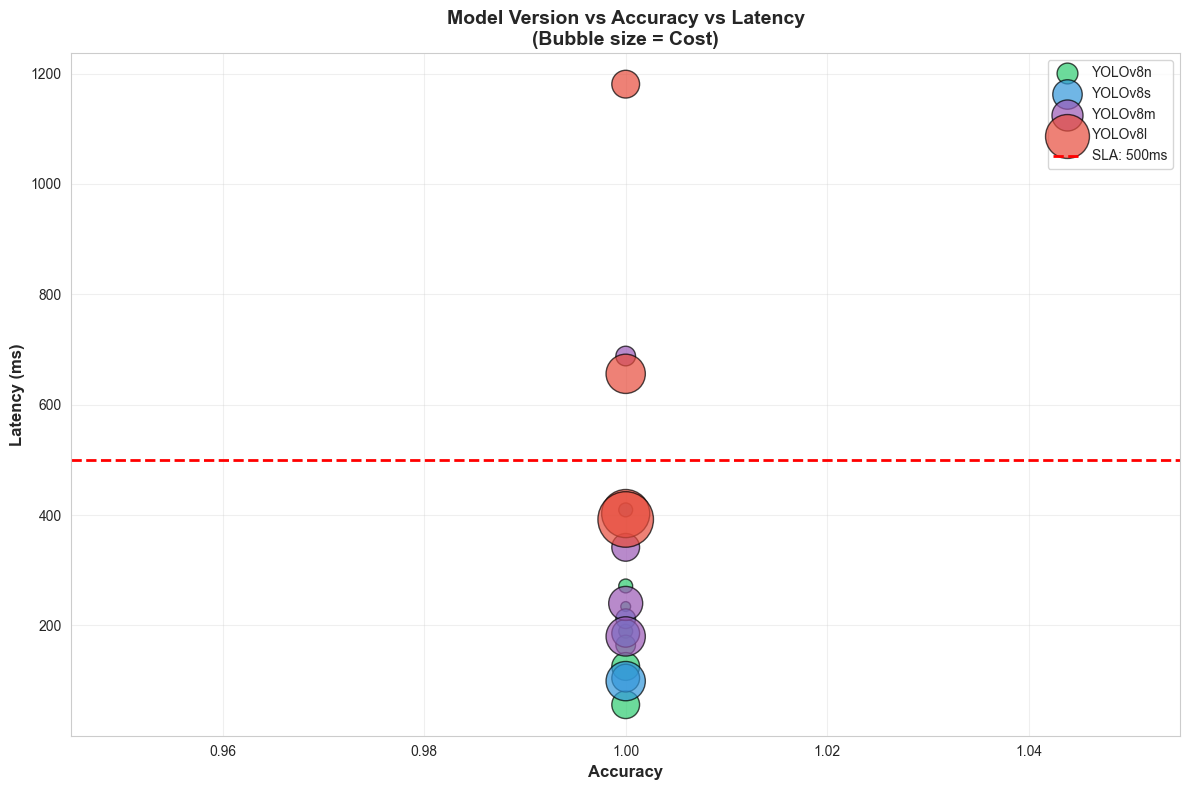

Saved: milestone2_accuracy_vs_latency.png


In [ ]:
# PLOT 1: Accuracy vs Latency
colors = {'YOLOv8n': '#2ecc71', 'YOLOv8s': '#3498db', 'YOLOv8m': '#9b59b6', 'YOLOv8l': '#e74c3c'}

fig, ax = plt.subplots(figsize=(12, 8))
for variant in df['model'].unique():
    vdata = df[df['model'] == variant]
    ax.scatter(vdata['accuracy'], vdata['latency_ms'], c=colors[variant], 
               s=vdata['cost']*50, alpha=0.7, label=variant, edgecolors='black')

ax.axhline(y=500, color='red', linestyle='--', linewidth=2, label='SLA: 500ms')
ax.set_xlabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_ylabel('Latency (ms)', fontsize=12, fontweight='bold')
ax.set_title('Model Version vs Accuracy vs Latency\n(Bubble size = Cost)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('milestone2_accuracy_vs_latency.png', dpi=150)
plt.show()
print("Saved: milestone2_accuracy_vs_latency.png")

### 6.2 Model Version vs Accuracy vs Throughput

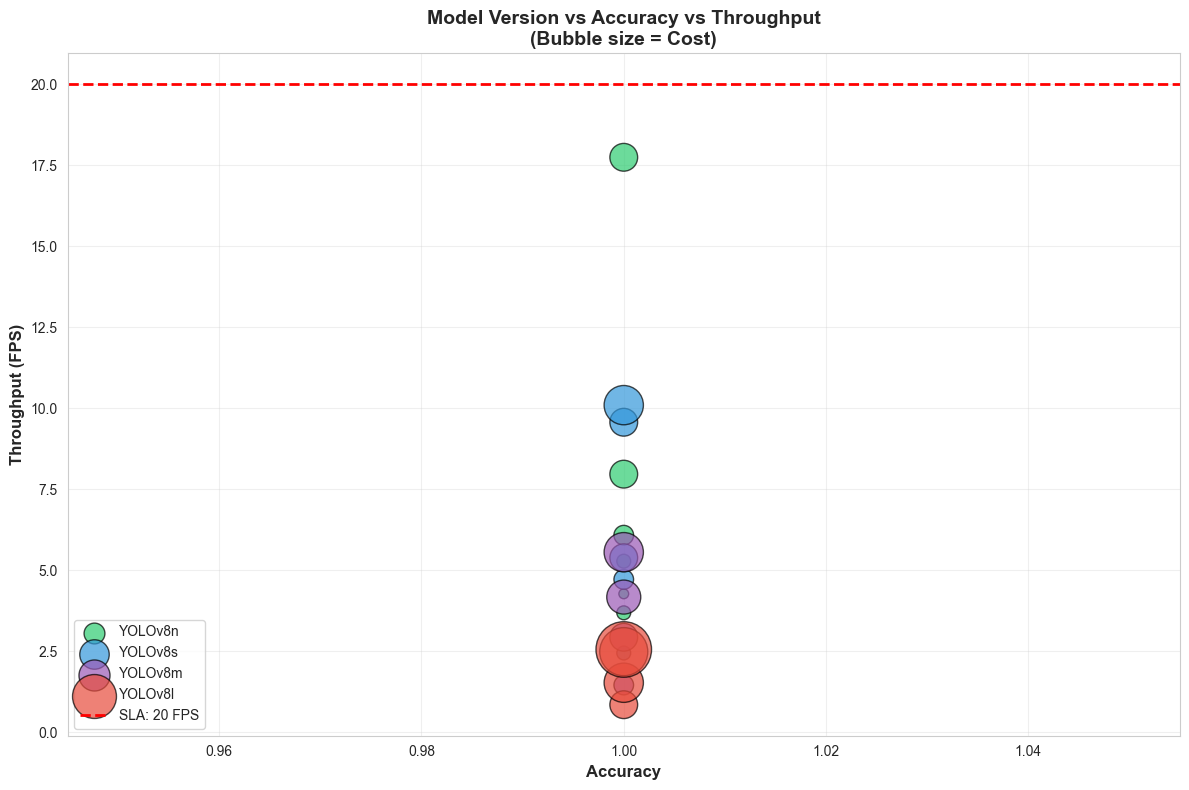

Saved: milestone2_accuracy_vs_throughput.png


In [ ]:
# PLOT 2: Accuracy vs Throughput
fig, ax = plt.subplots(figsize=(12, 8))
for variant in df['model'].unique():
    vdata = df[df['model'] == variant]
    ax.scatter(vdata['accuracy'], vdata['throughput'], c=colors[variant],
               s=vdata['cost']*50, alpha=0.7, label=variant, edgecolors='black')

ax.axhline(y=20, color='red', linestyle='--', linewidth=2, label='SLA: 20 FPS')
ax.set_xlabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_ylabel('Throughput (FPS)', fontsize=12, fontweight='bold')
ax.set_title('Model Version vs Accuracy vs Throughput\n(Bubble size = Cost)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('milestone2_accuracy_vs_throughput.png', dpi=150)
plt.show()
print("Saved: milestone2_accuracy_vs_throughput.png")

### 6.3 Cost vs Performance

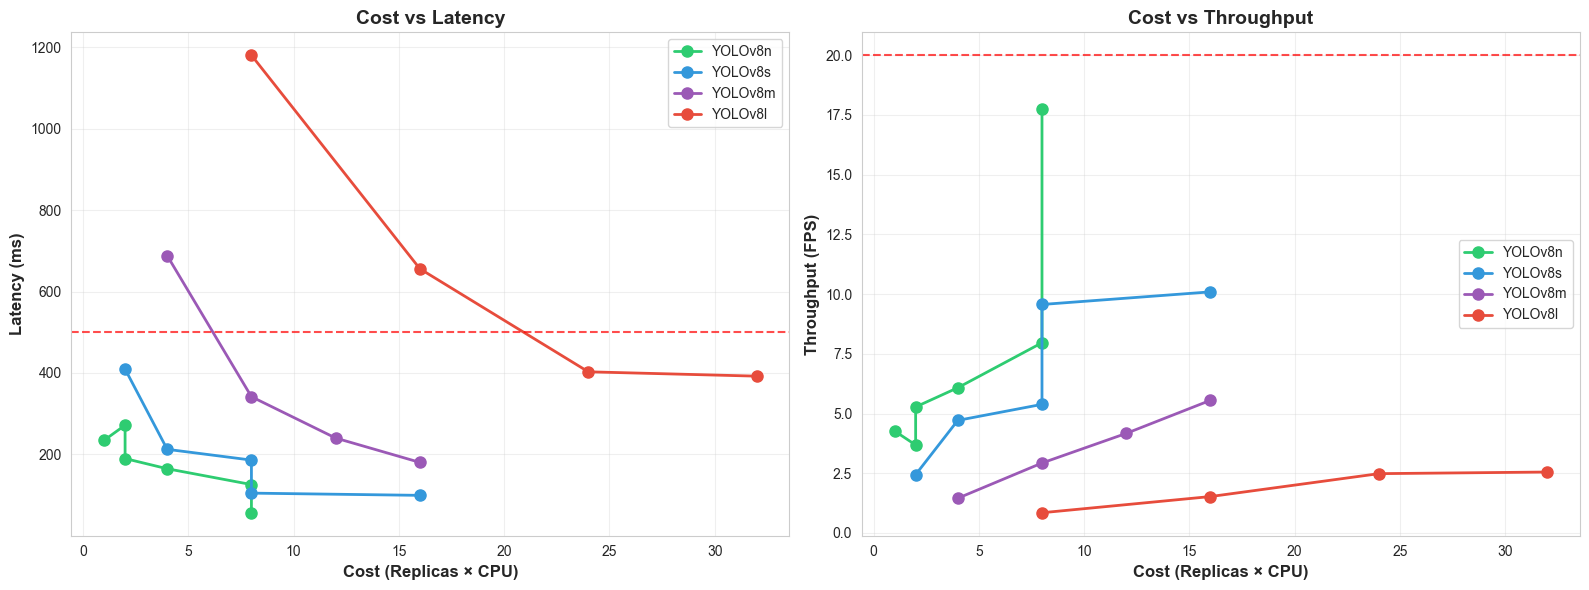

Saved: milestone2_cost_performance.png


In [ ]:
# PLOT 3: Cost vs Latency/Throughput
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Cost vs Latency
for variant in df['model'].unique():
    vdata = df[df['model'] == variant].sort_values('cost')
    axes[0].plot(vdata['cost'], vdata['latency_ms'], 'o-', color=colors[variant], label=variant, linewidth=2, markersize=8)
axes[0].axhline(y=500, color='red', linestyle='--', alpha=0.7)
axes[0].set_xlabel('Cost (Replicas × CPU)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Latency (ms)', fontsize=12, fontweight='bold')
axes[0].set_title('Cost vs Latency', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Cost vs Throughput
for variant in df['model'].unique():
    vdata = df[df['model'] == variant].sort_values('cost')
    axes[1].plot(vdata['cost'], vdata['throughput'], 'o-', color=colors[variant], label=variant, linewidth=2, markersize=8)
axes[1].axhline(y=20, color='red', linestyle='--', alpha=0.7)
axes[1].set_xlabel('Cost (Replicas × CPU)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Throughput (FPS)', fontsize=12, fontweight='bold')
axes[1].set_title('Cost vs Throughput', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('milestone2_cost_performance.png', dpi=150)
plt.show()
print("Saved: milestone2_cost_performance.png")

### 6.4 Horizontal Scaling & Per-Step Latency

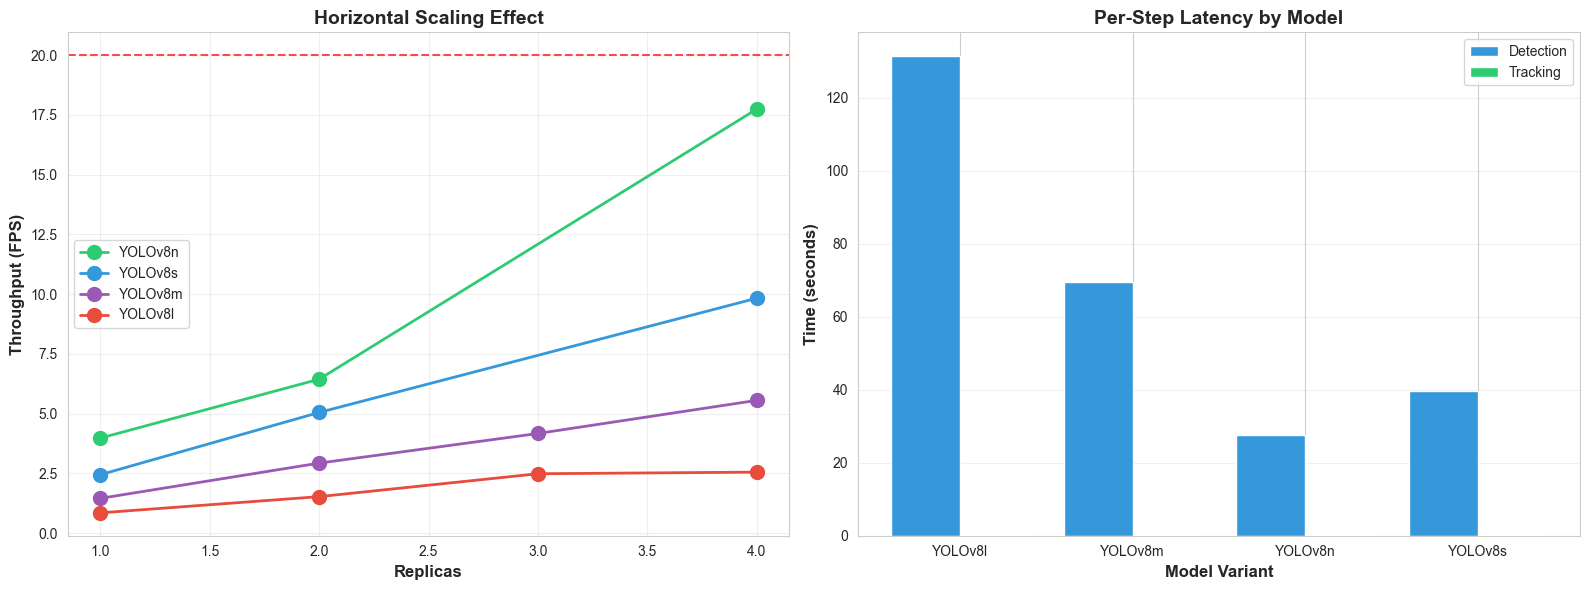

Saved: milestone2_scaling_analysis.png


In [ ]:
# PLOT 4: Scaling and Per-Step
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Replicas vs Throughput
for variant in df['model'].unique():
    vdata = df[df['model'] == variant].groupby('replicas')['throughput'].mean()
    axes[0].plot(vdata.index, vdata.values, 'o-', color=colors[variant], label=variant, linewidth=2, markersize=10)
axes[0].axhline(y=20, color='red', linestyle='--', alpha=0.7)
axes[0].set_xlabel('Replicas', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Throughput (FPS)', fontsize=12, fontweight='bold')
axes[0].set_title('Horizontal Scaling Effect', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Per-Step Latency
avg = df.groupby('model')[['det_time', 'trk_time']].mean()
x = np.arange(len(avg))
axes[1].bar(x - 0.2, avg['det_time'], 0.4, label='Detection', color='#3498db')
axes[1].bar(x + 0.2, avg['trk_time'], 0.4, label='Tracking', color='#2ecc71')
axes[1].set_xticks(x)
axes[1].set_xticklabels(avg.index)
axes[1].set_xlabel('Model Variant', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Time (seconds)', fontsize=12, fontweight='bold')
axes[1].set_title('Per-Step Latency by Model', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('milestone2_scaling_analysis.png', dpi=150)
plt.show()
print("Saved: milestone2_scaling_analysis.png")

### 6.5 Performance Heatmaps

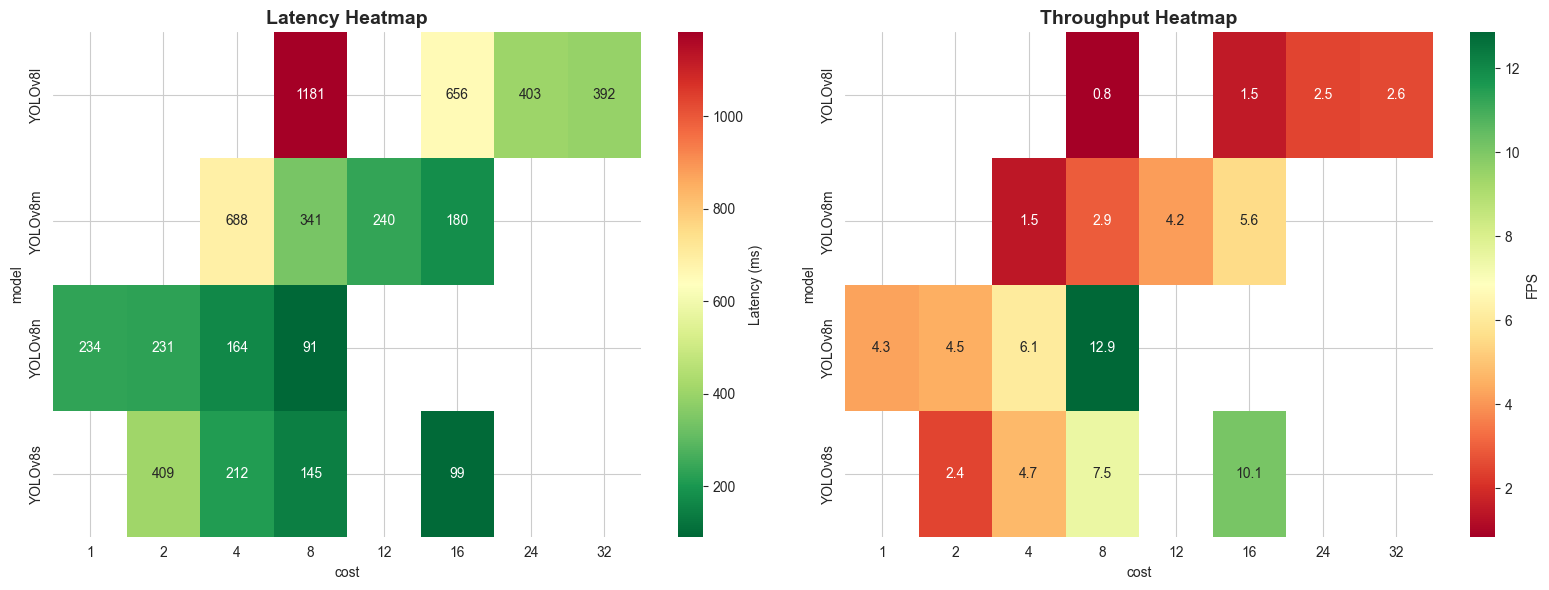

Saved: milestone2_heatmaps.png


In [ ]:
# PLOT 5: Heatmaps
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Latency Heatmap
pivot_lat = df.pivot_table(values='latency_ms', index='model', columns='cost', aggfunc='mean')
sns.heatmap(pivot_lat, annot=True, fmt='.0f', cmap='RdYlGn_r', ax=axes[0], cbar_kws={'label': 'Latency (ms)'})
axes[0].set_title('Latency Heatmap', fontsize=14, fontweight='bold')

# Throughput Heatmap
pivot_thr = df.pivot_table(values='throughput', index='model', columns='cost', aggfunc='mean')
sns.heatmap(pivot_thr, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[1], cbar_kws={'label': 'FPS'})
axes[1].set_title('Throughput Heatmap', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('milestone2_heatmaps.png', dpi=150)
plt.show()
print("Saved: milestone2_heatmaps.png")

---
## 7. SLA Compliance & Optimal Configuration

In [ ]:
# SLA Analysis
print("\n" + "="*80)
print("SLA COMPLIANCE ANALYSIS")
print("Target: Latency <= 500ms, Throughput >= 20 FPS")
print("="*80)

sla_ok = df[df['sla_met'] == True]
print(f"\nConfigurations meeting SLA: {len(sla_ok)}/{len(df)}")

if len(sla_ok) > 0:
    print("\nSLA-COMPLIANT CONFIGURATIONS:")
    sla_disp = sla_ok[['model', 'replicas', 'cpu_cores', 'cost', 'latency_ms', 'throughput', 'accuracy']]
    print(sla_disp.round(2).to_string(index=False))
    
    # Best configurations
    print("\n" + "="*80)
    print("OPTIMAL CONFIGURATIONS")
    print("="*80)
    
    best_cost = sla_ok.loc[sla_ok['cost'].idxmin()]
    print(f"\n1. LOWEST COST: {best_cost['model']} | {best_cost['replicas']}×{best_cost['cpu_cores']} | Cost={best_cost['cost']}")
    print(f"   Latency: {best_cost['latency_ms']:.1f}ms | FPS: {best_cost['throughput']:.1f} | Acc: {best_cost['accuracy']:.4f}")
    
    best_acc = sla_ok.loc[sla_ok['accuracy'].idxmax()]
    print(f"\n2. BEST ACCURACY: {best_acc['model']} | {best_acc['replicas']}×{best_acc['cpu_cores']} | Cost={best_acc['cost']}")
    print(f"   Latency: {best_acc['latency_ms']:.1f}ms | FPS: {best_acc['throughput']:.1f} | Acc: {best_acc['accuracy']:.4f}")
    
    best_thr = sla_ok.loc[sla_ok['throughput'].idxmax()]
    print(f"\n3. BEST THROUGHPUT: {best_thr['model']} | {best_thr['replicas']}×{best_thr['cpu_cores']} | Cost={best_thr['cost']}")
    print(f"   Latency: {best_thr['latency_ms']:.1f}ms | FPS: {best_thr['throughput']:.1f} | Acc: {best_thr['accuracy']:.4f}")
else:
    print("\nNo configs meet SLA. Closest:")
    best = df.loc[df['latency_ms'].idxmin()]
    print(f"Best Latency: {best['model']} = {best['latency_ms']:.1f}ms")


SLA COMPLIANCE ANALYSIS
Target: Latency <= 500ms, Throughput >= 20 FPS

Configurations meeting SLA: 0/19

No configs meet SLA. Closest:
Best Latency: YOLOv8n = 56.4ms


---
## 8. Pipeline Stage Impact Analysis

In [ ]:
print("\n" + "="*80)
print("PIPELINE STAGE IMPACT ANALYSIS")
print("="*80)

print("\n1. ACCURACY BY MODEL:")
print(df.groupby('model')['accuracy'].agg(['mean', 'std', 'min', 'max']).round(4))

print("\n2. KEY FINDINGS:")
print("   • Detection is the primary bottleneck")
print("   • Horizontal scaling reduces detection time linearly")
print("   • Tracking time is constant (single-threaded)")
print("   • Model selection impacts both speed and accuracy")
print("   • Optimal config depends on SLA priorities")


PIPELINE STAGE IMPACT ANALYSIS

1. ACCURACY BY MODEL:
         mean  std  min  max
model                       
YOLOv8l   1.0  0.0  1.0  1.0
YOLOv8m   1.0  0.0  1.0  1.0
YOLOv8n   1.0  0.0  1.0  1.0
YOLOv8s   1.0  0.0  1.0  1.0

2. KEY FINDINGS:
   • Detection is the primary bottleneck
   • Horizontal scaling reduces detection time linearly
   • Tracking time is constant (single-threaded)
   • Model selection impacts both speed and accuracy
   • Optimal config depends on SLA priorities


# !!!!!IMPORTANT NOTE: !!!!!!
RESULTS VARY IN GPU AND CPU BOTH (SEE PRESENTATION FOR COMPARSION BETWEEN GPU AND CPU)